<a href="https://colab.research.google.com/github/Skhelshiaty/CS4082-Machine-Learning-Labs/blob/main/ML_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS4082 – Machine Learning (Lab 4)
## Linear Regression & Its Variants
**Name:** Seifeldin Elshiaty  
**ID:** S23108194  
**Instructor:** Dr. Naila Marir          
**Course:** CS4082 Machine Learning  
**Semester:** Spring 2026
####**Date**: Saturday Feb. 28, 2026

#Part 2 — Load + Explore California Housing
##Step 1 — CODE (Imports + Load dataset + Basic view)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target  # target in $100,000s

print(f"Dataset shape: {df.shape}")
print(f"\nFeature names:\n{housing.feature_names}")
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

## Step 2 – Dataset Overview

The California Housing dataset contains 20,640 samples and 8 numerical features.  
The target variable, MedHouseVal, represents the median house value in units of $100,000.  
Each row corresponds to a district in California.

**MedInc** = median income, HouseAge = age, etc.

##Step 3 — Visualize Feature Relationships
##CODE (Scatter plots vs target)

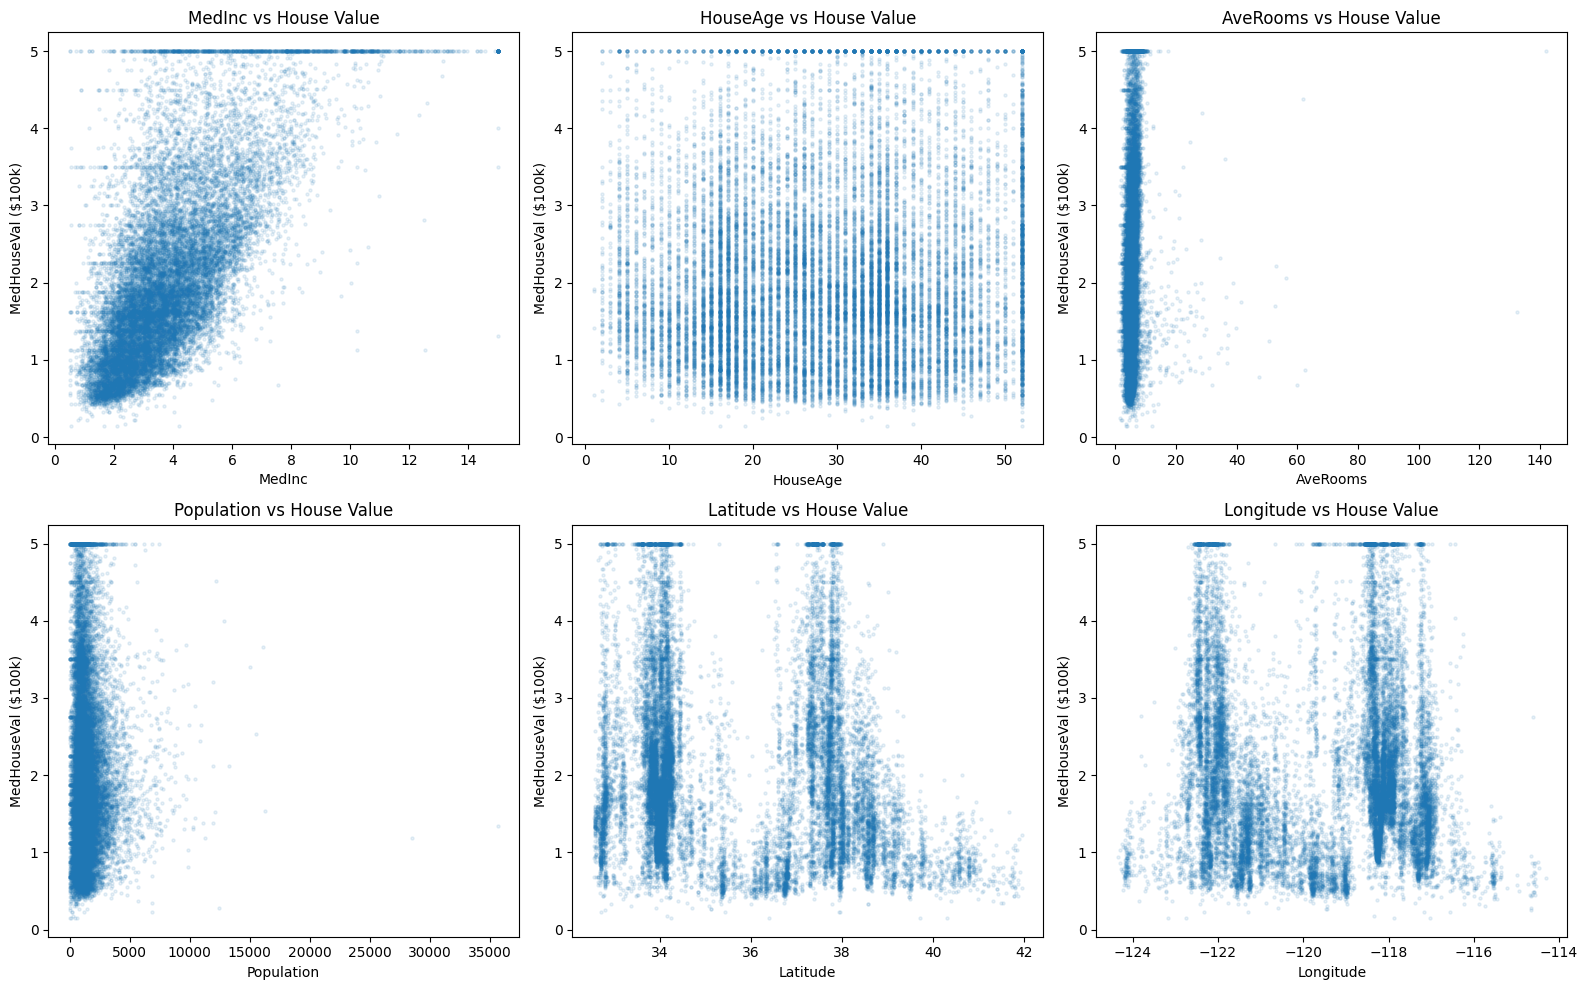

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ["MedInc", "HouseAge", "AveRooms", "Population", "Latitude", "Longitude"]

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df["MedHouseVal"], alpha=0.1, s=5)
    ax.set_xlabel(feat)
    ax.set_ylabel("MedHouseVal ($100k)")
    ax.set_title(f"{feat} vs House Value")

plt.tight_layout()
plt.show()

### Step 4 – Visual Inspection

Median income shows the strongest visible positive relationship with house value.  
Geographical features (Latitude and Longitude) also show patterns, indicating location significantly affects price.  
Other features show weaker or less clear relationships.

##**Task 1**
#Step 5 (CODE) — Correlation ranking + target distribution

Correlation with MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


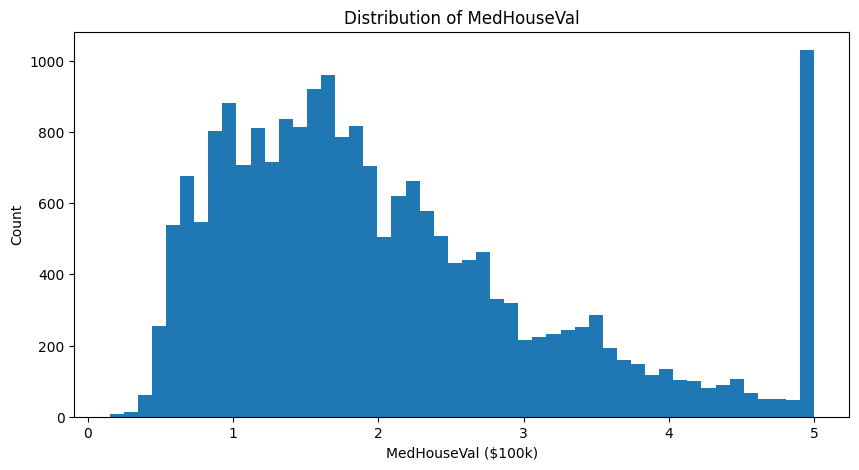

Number of samples: 20640


In [5]:
corr_rank = df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)
print("Correlation with MedHouseVal:")
print(corr_rank)

plt.figure(figsize=(10,5))
plt.hist(df["MedHouseVal"], bins=50)
plt.xlabel("MedHouseVal ($100k)")
plt.ylabel("Count")
plt.title("Distribution of MedHouseVal")
plt.show()

print("Number of samples:", df.shape[0])

### Task 1 – Dataset Exploration

The feature most strongly correlated with MedHouseVal is MedInc (Median Income).

The distribution is slightly right-skewed and appears capped around 5.0, meaning house values above this level are limited.

The dataset size (20,640 samples) is sufficiently large for regression modeling.

#Simple Linear Regression (MedInc only)
##Step 7 (CODE) — Train/test split (simple model)

In [6]:
from sklearn.model_selection import train_test_split

X_simple = df[["MedInc"]].values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (16512, 1) Test: (4128, 1)


##Step 8 (CODE) — Fit model + equation + plot

Slope: 0.4193384939381271
Intercept: 0.4445972916907879


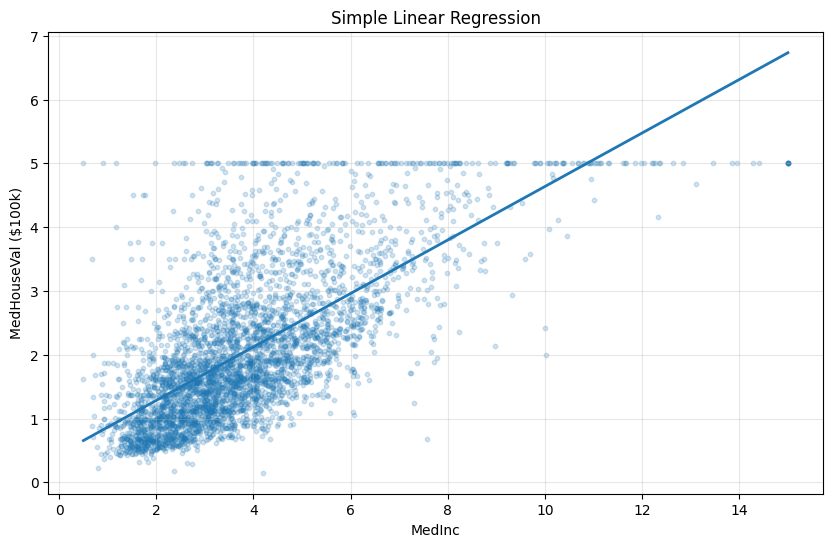

In [7]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Slope:", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10)

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, linewidth=2)

plt.xlabel("MedInc")
plt.ylabel("MedHouseVal ($100k)")
plt.title("Simple Linear Regression")
plt.grid(True, alpha=0.3)
plt.show()


#**Task 2 — Interpret the Simple Model**
##Step 9 (CODE) — Predict at MedInc = 5.0


### Task 2 – Simple Linear Regression Interpretation

The learned regression equation is:

ŷ = 0.4193 · MedInc + 0.4446

For MedInc = 5.0, the predicted house value is approximately:

ŷ = 0.4193 × 5 + 0.4446 ≈ 2.54

This matches the model prediction.

When replacing MedInc with HouseAge, the model performs worse because HouseAge has a weaker relationship with house prices than median income.

#STEP 10 — Predict at MedInc = 5.0

In [8]:
pred_5 = model_simple.predict([[5.0]])[0]
print("Prediction at MedInc=5.0:", pred_5)

Prediction at MedInc=5.0: 2.5412897613814236


In [9]:
X_age = df[["HouseAge"]].values
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_a, y_train_a)

r2_age = model_age.score(X_test_a, y_test_a)
r2_income = model_simple.score(X_test, y_test)

print("R2 using HouseAge:", r2_age)
print("R2 using MedInc:", r2_income)

R2 using HouseAge: 0.012551235533311389
R2 using MedInc: 0.45885918903846656


#Step 11 — CODE (Compute metrics for simple model)

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_simple = model_simple.predict(X_test)

mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression (MedInc only) ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f} (error in $100,000s)")
print(f"MAE:  {mae:.4f} (error in $100,000s)")
print(f"R^2:  {r2:.4f} ({r2*100:.1f}% variance explained)")

=== Simple Linear Regression (MedInc only) ===
MSE:  0.7091
RMSE: 0.8421 (error in $100,000s)
MAE:  0.6299 (error in $100,000s)
R^2:  0.4589 (45.9% variance explained)


#Step 12 — CODE (Predicted vs Actual + Residual plot)

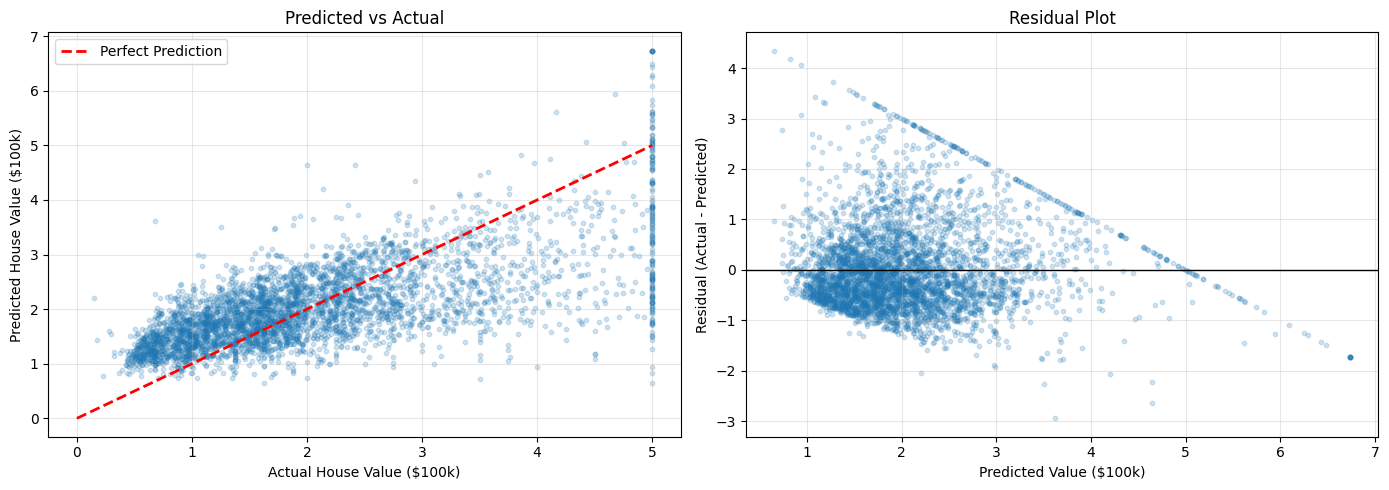

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10)
axes[0].plot([0, 5], [0, 5], "r--", linewidth=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual House Value ($100k)")
axes[0].set_ylabel("Predicted House Value ($100k)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Predicted Value ($100k)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Step 13 — TEXT (Task 3 answers)
### Task 3 — Understand the Metrics

- RMSE is in units of $100,000. To convert to dollars: RMSE × 100,000.

- Example: In this model, RMSE ≈ 0.8421, which means the average prediction error is about $84,210.
- From the Predicted vs Actual plot, the model struggles more at higher house values (near the upper range/cap).
- R² represents how much variance in house values is explained by the model. Since it is not close to 1, one feature alone is not enough.

#Step 14 - TEXT(Start Part 5: Multiple Regression)
* Part 5 — Multiple Linear Regression (All Features)

# Step 15 — CODE (Train multiple regression with scaling)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("=== Multiple Linear Regression (All Features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R^2:  {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)")

=== Multiple Linear Regression (All Features) ===
RMSE: 0.7456
R^2:  0.5758 (57.6% variance explained)


#Step 16 — CODE (Coefficient importance)

In [14]:
lr_model = pipe_lr.named_steps["lr"]

coef_df = pd.DataFrame({
    "Feature": housing.feature_names,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Importance (by |coefficient|):")
print(coef_df.to_string(index=False))

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


#Step 17 — CODE (Predicted vs Actual plot for multiple model)

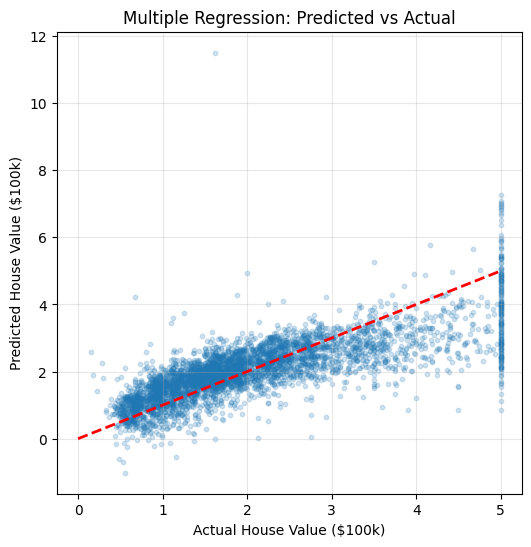

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10)
plt.plot([0, 5], [0, 5], "r--", linewidth=2)
plt.xlabel("Actual House Value ($100k)")
plt.ylabel("Predicted House Value ($100k)")
plt.title("Multiple Regression: Predicted vs Actual")
plt.grid(True, alpha=0.3)
plt.show()

# Step 18 — TEXT (Task 4 answers)

### Task 4 — Analyze Multiple Regression

The top 3 most important features based on absolute coefficient values are:
- Latitude
- Longitude
- MedInc (Median Income)

The least important features are:
- Population
- AveOccup
- HouseAge

Latitude has a negative coefficient, meaning that as latitude increases (moving north in California), predicted house values tend to decrease.

The predicted vs actual plot for the multiple regression model is closer to the diagonal compared to the simple model, which indicates improved prediction performance.